# Credit Risk Classification Using Machine Learning on the German Credit Dataset

---

# Objective:

- To develop and evaluate multiple supervised machine learning models for predicting credit risk (good vs. bad credit) using the German Credit Dataset.
- The goal is to identify the most effective model using performance metrics such as ROC AUC, accuracy, precision, recall, and F1-score, both via an 80-20 train-test split and 5-fold cross-validation.

---

# Methodology:

- Data Source: Used the publicly available German Credit Dataset containing 1000 loan applicants described by 20 categorical and numerical features, labeled as good or bad credit risk.
  
- Exploratory Data Analysis (EDA):
 - Inspected feature distributions using histograms and boxplots.
 - Evaluated class balance (700 good, 300 bad).
 - Checked for missing values and correlations among numerical features using a heatmap.
   
- Data Preprocessing:
  - Handled categorical variables using one hot encoding.
  - Scaled numerical features where necessary to improve model performance.
    
- Model Evaluation Approach:
  - 80-20 Train-Test Split:
    - Stratified split with 80% training and 20% testing.
    - Pipeline with preprocessing and classification for each model.
    - Evaluated using:
      - ROC AUC
      - Accuracy, Precision, Recall, and F1-score
      - ROC curve visualization.
 - 5-Fold Cross-Validation:
   - Used StratifiedKFold to ensure balanced classes across folds.
   - Evaluated mean AUC across folds for each model.

- Models Implemented:
  - Logistic Regression
  - Support Vector Machine (SVM)
  - Random Forest Classifier
  - XGBoost Classifier
  - K-Nearest Neighbors (KNN)
 
- Tools and Libraries: Python, with scikit-learn, xgboost, pandas, numpy, matplotlib, and seaborn.

---

# Key Findings:

- From 80-20 Train-Test Split:
  - Logistic Regression delivered the highest AUC (~0.819) and balanced overall performance, confirming its effectiveness for linear classification in this context.
  - Random Forest and XGBoost had comparable AUCs (~0.811), but XGBoost showed better recall (0.53), making it more suitable for detecting risky applicants.
  - SVM maintained high precision but had low recall (0.28), limiting its utility in identifying bad credit cases.
  - KNN underperformed (AUC ~ 0.689), consistent with challenges in high dimensional tabular data.
 
- From 5-Fold Cross-Validation:
  - Logistic Regression had the best average AUC (~0.787), again confirming its stability across folds.
  - SVM and Random Forest followed closely (AUC ~0.781), showing consistent but slightly lower performance.
  - XGBoost slightly underperformed (AUC ~0.773), indicating higher variance and sensitivity to data splits.
  - KNN remained the least effective model (AUC ~0.684), again confirming its unsuitability for this task.

---

# Conclusions:

 - The project effectively demonstrates both holdout based and cross validated model evaluation for credit risk prediction.
 - Logistic Regression emerged as the most consistent and interpretable model.
 - XGBoost and Random Forest offer powerful alternatives with good generalization but may require more careful tuning.
 - SVM had strong precision but lower recall, indicating trade offs in minority class detection.
 - KNN is not well-suited to this type of data.

---

# Code and analysis:


Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report


Dataset

German Credit Dataset Summary:

- Source: Prof. Dr. Hans Hofmann, University of Hamburg. Availble at https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data.
- Instances: 1000
- Attributes: 20 features (7 numerical, 13 categorical). The attributes are:
Status, Duration, CreditHistory, Purpose, CreditAmount, Savings, EmploymentSince, InstallmentRate, PersonalStatusSex, OtherDebtors, ResidenceSince, Property, Age, OtherInstallmentPlans, Housing, ExistingCredits, Job, LiablePeople, Telephone, ForeignWorker.
- Label (Target):
  - 1: Good credit
  - 2: Bad credit
- Description: This dataset classifies people described by a set of attributes as good (1) or bad (2) credit risks. The original version (german.data) includes categorical variables with symbolic codes. The numeric version (german.data-numeric) is preprocessed for use with algorithms requiring numeric input.



In [2]:
columns = [
    'Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount', 'Savings',
    'EmploymentSince', 'InstallmentRate', 'PersonalStatusSex', 'OtherDebtors',
    'ResidenceSince', 'Property', 'Age', 'OtherInstallmentPlans', 'Housing',
    'ExistingCredits', 'Job', 'LiablePeople', 'Telephone', 'ForeignWorker', 'Target'
]


df = pd.read_csv('german.data', sep=' ', header=None, names=columns)
df.head()


,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,EmploymentSince,InstallmentRate,PersonalStatusSex,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,LiablePeople,Telephone,ForeignWorker,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:

# Convert target to binary: 1 = good, 2 = bad → make 1 = 0, 2 = 1
df['Target'] = df['Target'].map({1: 0, 2: 1})
# Separate features and target
X = df.drop('Target', axis=1)
y = df['Target']

# Encode categorical features
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()


Check for null values

In [4]:
df.isnull().sum()

Status                   0
Duration                 0
CreditHistory            0
Purpose                  0
CreditAmount             0
Savings                  0
EmploymentSince          0
InstallmentRate          0
PersonalStatusSex        0
OtherDebtors             0
ResidenceSince           0
Property                 0
Age                      0
OtherInstallmentPlans    0
Housing                  0
ExistingCredits          0
Job                      0
LiablePeople             0
Telephone                0
ForeignWorker            0
Target                   0
dtype: int64

Basic info of the dataset

In [5]:
print("Dataset Shape:")
print(df.shape)
print("\n Data Types:")
print(df.dtypes)
print("\n Descriptive Statistics:")
print(df.describe())

Dataset Shape:
(1000, 21)

 Data Types:
Status                   object
Duration                  int64
CreditHistory            object
Purpose                  object
CreditAmount              int64
Savings                  object
EmploymentSince          object
InstallmentRate           int64
PersonalStatusSex        object
OtherDebtors             object
ResidenceSince            int64
Property                 object
Age                       int64
OtherInstallmentPlans    object
Housing                  object
ExistingCredits           int64
Job                      object
LiablePeople              int64
Telephone                object
ForeignWorker            object
Target                    int64
dtype: object

 Descriptive Statistics:
          Duration  CreditAmount  InstallmentRate  ResidenceSince  \
count  1000.000000   1000.000000      1000.000000     1000.000000   
mean     20.903000   3271.258000         2.973000        2.845000   
std      12.058814   2822.736876         

Class Distribution

Target
0    700
1    300
Name: count, dtype: int64


<Axes: xlabel='Target'>

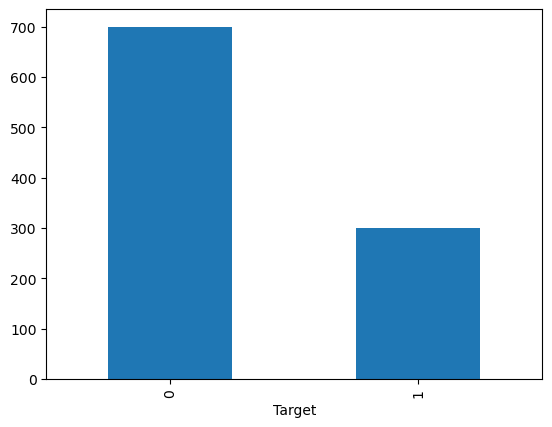

In [6]:
print(df['Target'].value_counts())
df['Target'].value_counts().plot(kind='bar')

Feature distributions

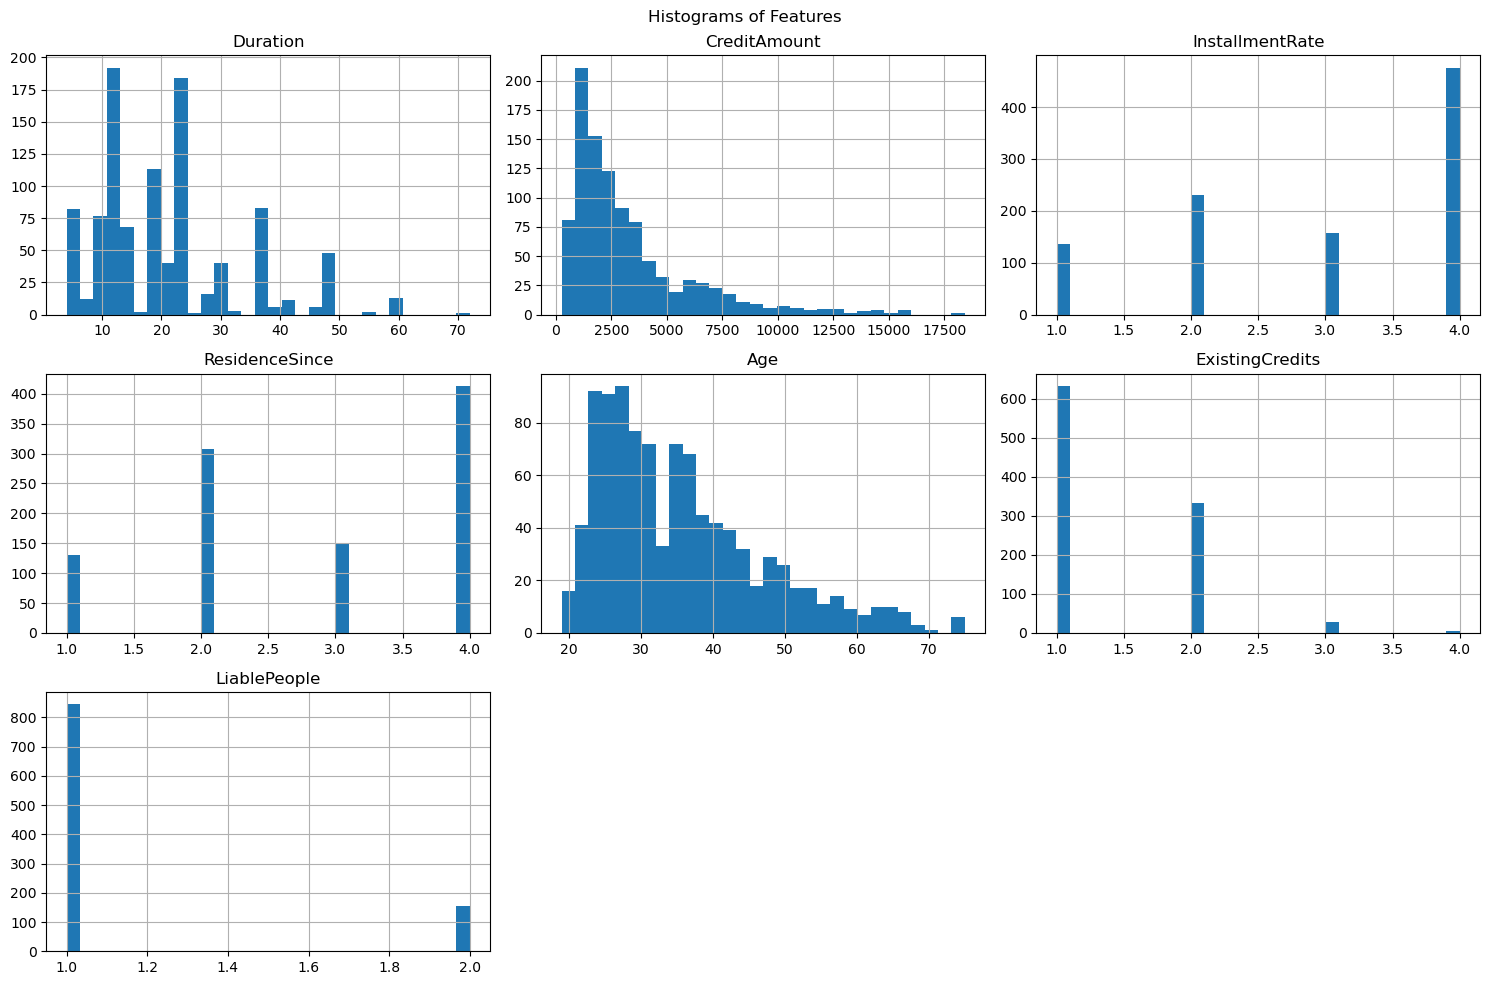

In [7]:
df[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms of Features")
plt.tight_layout()
plt.show()

Boxplots for outlier detection

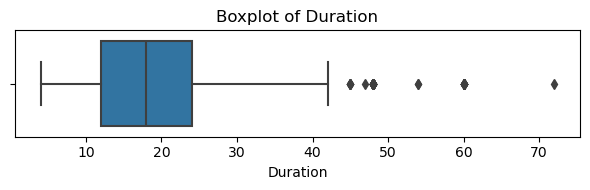

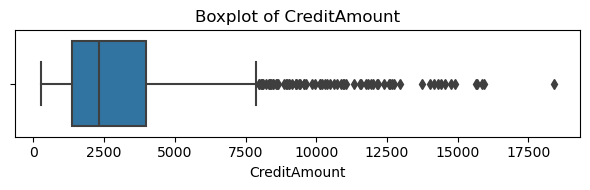

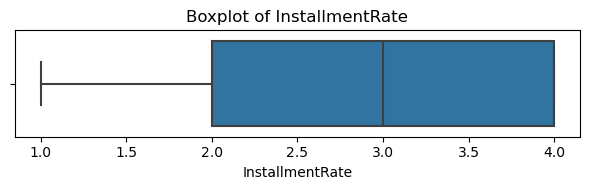

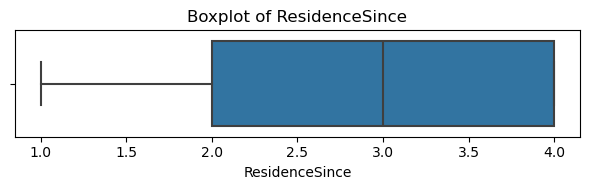

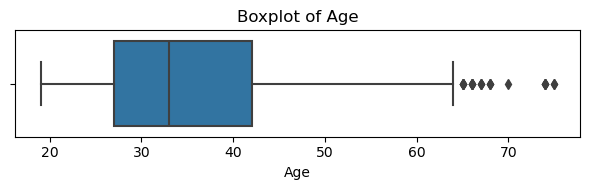

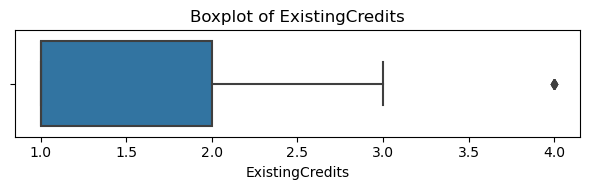

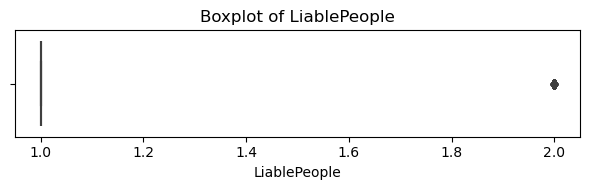

In [8]:
for col in numerical_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

Correlation heatmap

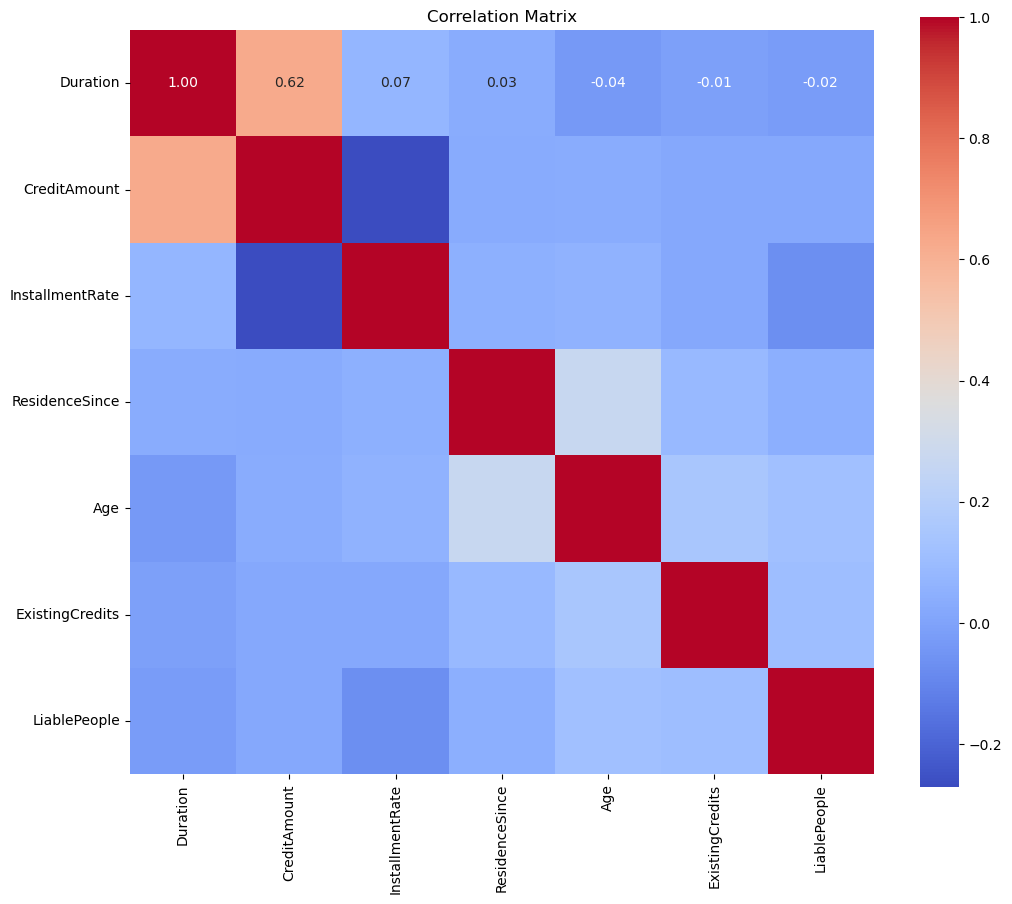

In [9]:
plt.figure(figsize=(12, 10))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.show()

Create preprocessing pipeline

In [10]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])


Define models

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=100),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=100),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}


 Logistic Regression : 
              precision    recall  f1-score   support

           0     0.8052    0.8857    0.8435       140
           1     0.6522    0.5000    0.5660        60

    accuracy                         0.7700       200
   macro avg     0.7287    0.6929    0.7048       200
weighted avg     0.7593    0.7700    0.7603       200


 SVM : 
              precision    recall  f1-score   support

           0     0.7584    0.9643    0.8491       140
           1     0.7727    0.2833    0.4146        60

    accuracy                         0.7600       200
   macro avg     0.7656    0.6238    0.6318       200
weighted avg     0.7627    0.7600    0.7187       200


 Random Forest : 
              precision    recall  f1-score   support

           0     0.7765    0.9429    0.8516       140
           1     0.7333    0.3667    0.4889        60

    accuracy                         0.7700       200
   macro avg     0.7549    0.6548    0.6703       200
weighted avg     0.76

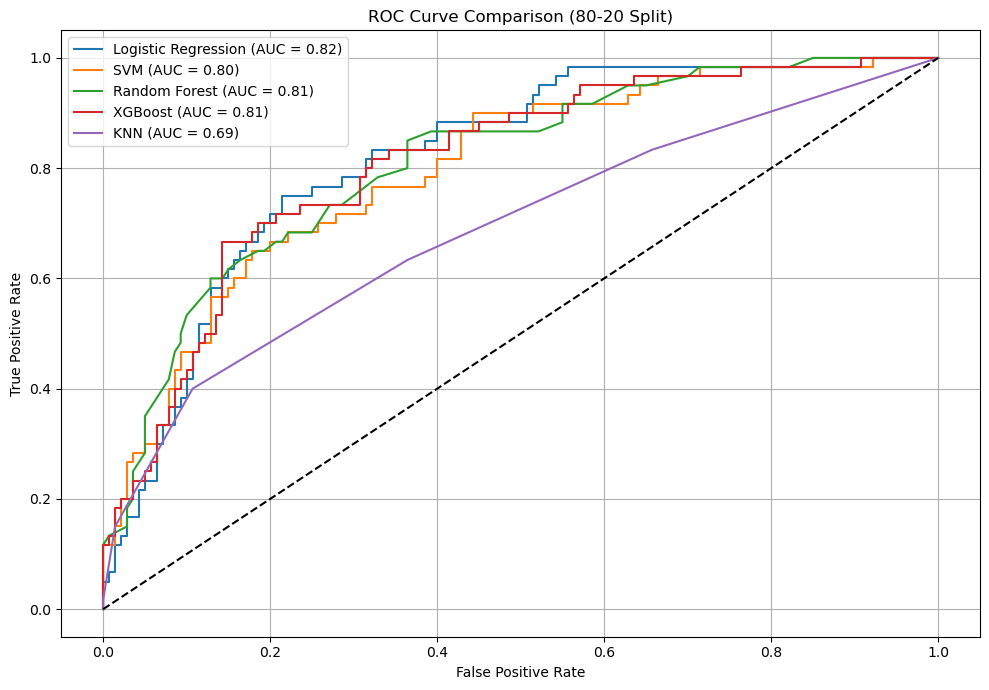

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=100)

plt.figure(figsize=(10, 7))
results = {}

for name, model in models.items():
    print(f"\n {name} : ")

    # Pipeline with preprocessing and model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'AUC': auc
    }

    print(classification_report(y_test, y_pred, digits=4))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (80-20 Split)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Summary

In [13]:
print(pd.DataFrame(results))

           Logistic Regression       SVM  Random Forest   XGBoost       KNN
Accuracy              0.770000  0.760000       0.770000  0.765000  0.745000
Precision             0.652174  0.772727       0.733333  0.627451  0.615385
Recall                0.500000  0.283333       0.366667  0.533333  0.400000
F1 Score              0.566038  0.414634       0.488889  0.576577  0.484848
AUC                   0.818571  0.799405       0.811012  0.810595  0.688631


Using 5-fold cross validation

In [14]:
cv_results = []  

for seed in range(20,40,2):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    
    for name, model in models.items():
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        
        auc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
        
        
        for fold_idx, score in enumerate(auc_scores):
            cv_results.append({
                'model': name,
                'seed': seed,
                'fold': fold_idx,
                'auc': score
            })



In [15]:
df_cv_scores = pd.DataFrame(cv_results)
df_model_avg = df_cv_scores.groupby('model')['auc'].mean().reset_index()
df_model_avg = df_model_avg.sort_values(by='auc', ascending=False)
print(df_model_avg)

                 model       auc
1  Logistic Regression  0.787188
2        Random Forest  0.780689
3                  SVM  0.780171
4              XGBoost  0.772850
0                  KNN  0.684460


Based on the average AUC scores, Logistic Regression outperformed the other models. Random Forest and SVM followed closely behind with comparable performance. XGBoost showed slightly lower performance, while KNN had the lowest AUC score among all models.